# **FREmu: Power Spectrum Emulator for f(R) Gravity**

**FREmu** is a neural-network-based emulator designed to predict the non-linear matter power spectrum in the Hu-Sawicki f(R) gravity model. It offers rapid and accurate forecasts across scales $0.0089 \, h \, \mathrm{Mpc}^{-1} < k < 0.5 \, h \, \mathrm{Mpc}^{-1}$ and redshifts $0 < z < 3$ .

### Key Features

* **Set cosmological parameters**
* **Retrieve power spectra**
* **Compute boost factors**
* **Estimate errors**

### Technical Overview

FREmu employs Principal Component Analysis (PCA) and Artificial Neural Networks (ANNs) to map cosmological parameters to power spectra. It is trained on data from the Quijote-MG simulation suite, encompassing a 7-dimensional parameter space:

* $\Omega_m$ (matter density fraction)
* $\Omega_b$ (baryon density fraction)
* $h$ (Hubble constant)
* $n_s$ (scalar spectral index)
* $\sigma_8$ (amplitude of matter fluctuations)
* $M_{\nu}$ (neutrino mass)
* $f_{R_0}$ (f(R) gravity parameter)

The emulator achieves over 95% accuracy in most cases, making it a valuable tool for cosmological parameter inference .

### Access & Documentation

* GitHub Repository: [https://github.com/AstroBai/FREmu](https://github.com/AstroBai/FREmu)
* Research Paper: [FREmu: Power Spectrum Emulator for f(R) Gravity](https://iopscience.iop.org/article/10.3847/1538-4357/ad55ef)

---

- # **Installation**

In [1]:
pip install -q fremu

- # **Initialize the FREmu emulator**

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
from fremu import fremu

# Initialize the emulator
emu = fremu.emulator()

- # **Set the cosmological parameters**

In [3]:
# Set cosmological parameters
emu.set_cosmo(Om=0.3, Ob=0.05, h=0.7, ns=1.0, sigma8=0.8, mnu=0.05, fR0=-3e-5)

- # **To generate an array of wave numbers (`k_values`) that are logarithmically spaced between $10^{-3}$ and $10^{1}$, inclusive, with 100 points**

In [4]:
import numpy as np

# Define wave numbers
k_values = np.logspace(-3, 1, 100)

- # **To compute the **non-linear matter power spectrum** at a specific **redshift** (in this case, $z = 0.5$) and for a set of **wavenumbers** $k$.**

In [5]:
# Get power spectrum at redshift z and wave numbers k
power_spectrum = emu.get_power_spectrum(k=k_values, z=0.5)

- # **Matter Power Spectrum**

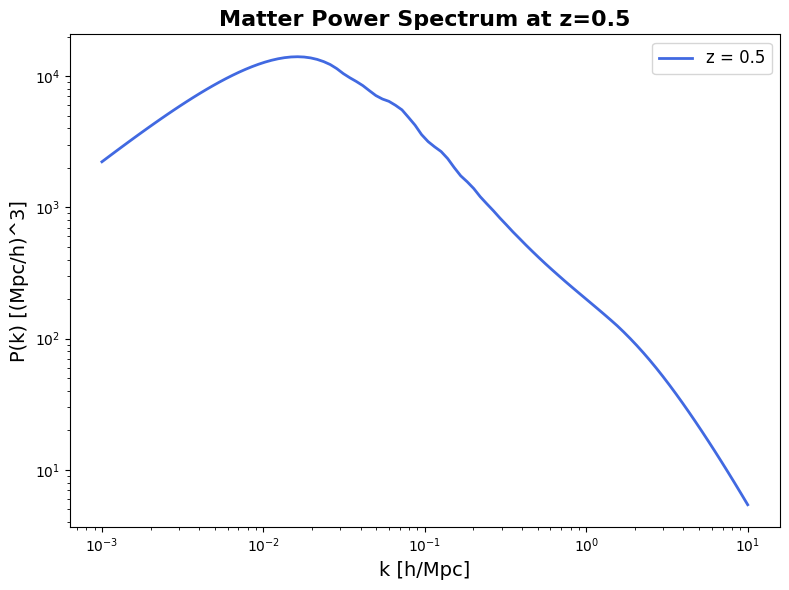

In [6]:
import matplotlib.pyplot as plt

# Example improved plot
plt.figure(figsize=(8, 6))  # Larger figure
plt.loglog(k_values, power_spectrum, label="z = 0.5", color='royalblue', linewidth=2)

# Axis labels with larger font
plt.xlabel("k [h/Mpc]", fontsize=14)
plt.ylabel("P(k) [(Mpc/h)^3]", fontsize=14)

# Title
plt.title("Matter Power Spectrum at z=0.5", fontsize=16, fontweight='bold')

# Grid for better readability
#plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Legend with frame
plt.legend(frameon=True, fontsize=12)

# Optional: tighten layout for better spacing
plt.tight_layout()

# Show plot
plt.show()

- # **Multi-redshift power spectra**

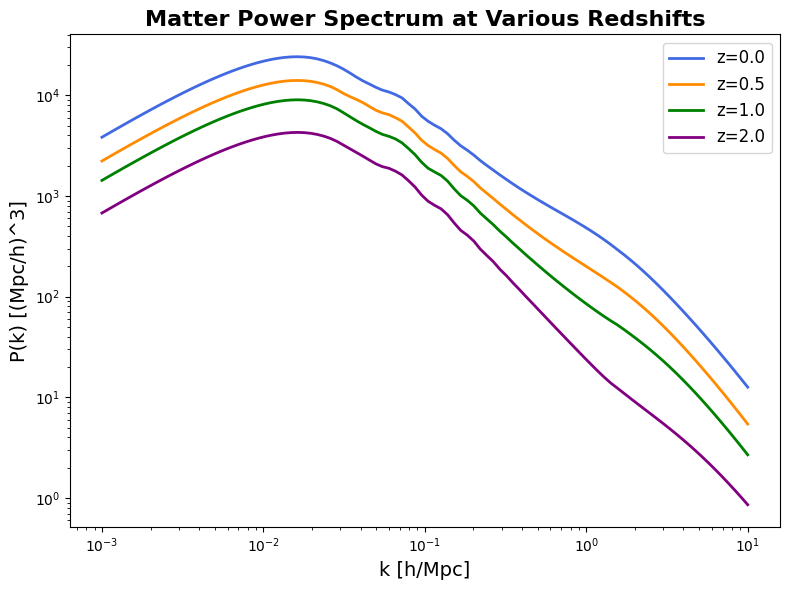

In [7]:
# Example z values
z_values = [0.0, 0.5, 1.0, 2.0]

# Optional: define colors for each redshift for clarity
colors = ['royalblue', 'darkorange', 'green', 'purple']

plt.figure(figsize=(8, 6))  # Larger figure

for i, z in enumerate(z_values):
    pk = emu.get_power_spectrum(k=k_values, z=z)
    plt.loglog(k_values, pk, label=f"z={z}", color=colors[i], linewidth=2)

# Axis labels with larger font
plt.xlabel("k [h/Mpc]", fontsize=14)
plt.ylabel("P(k) [(Mpc/h)^3]", fontsize=14)

# Title
plt.title("Matter Power Spectrum at Various Redshifts", fontsize=16, fontweight='bold')

# Grid for readability
#plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Legend with frame and larger font
plt.legend(frameon=True, fontsize=12)

# Tight layout for better spacing
plt.tight_layout()

# Show plot
plt.show()

- # **fR0 impacts on power spectra**

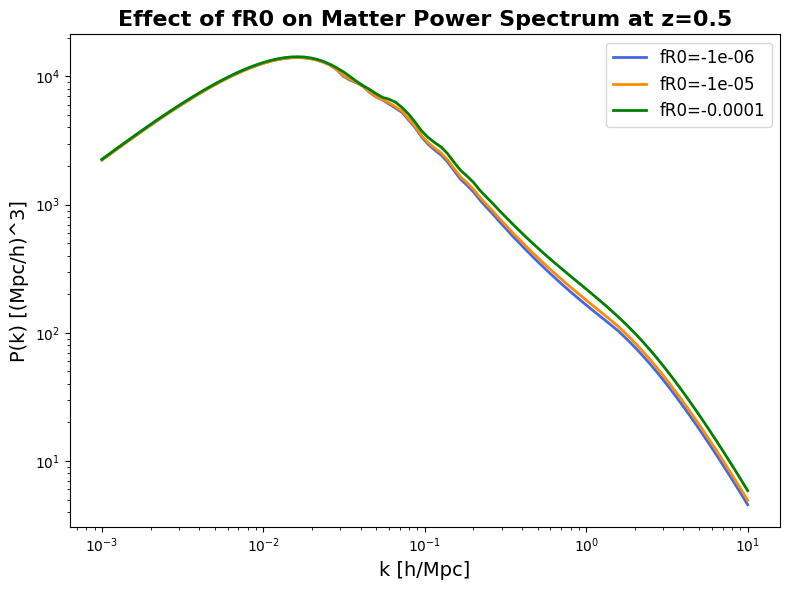

In [11]:
fR0_values = [-1e-6, -1e-5, -1e-4]
colors = ['royalblue', 'darkorange', 'green']

plt.figure(figsize=(8,6))

for i, fR0 in enumerate(fR0_values):
    emu.set_cosmo(Om=0.3, Ob=0.05, h=0.7, ns=1.0, sigma8=0.8, mnu=0.05, fR0=fR0)
    pk = emu.get_power_spectrum(k=k_values, z=0.5)
    plt.loglog(k_values, pk, color=colors[i], label=f'fR0={fR0}', linewidth=2)

plt.xlabel("k [h/Mpc]", fontsize=14)
plt.ylabel("P(k) [(Mpc/h)^3]", fontsize=14)
plt.title("Effect of fR0 on Matter Power Spectrum at z=0.5", fontsize=16, fontweight='bold')
plt.legend(frameon=True, fontsize=12)
plt.tight_layout()
plt.show()